In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline 
from sklearn import set_config

In [2]:
set_config(transform_output = 'pandas')

In [3]:
df =  pd.read_csv('../data/hiv_preprocessed_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   age                             349 non-null    int64
 1   marital_status                  349 non-null    str  
 2   std                             349 non-null    str  
 3   educational_background          349 non-null    str  
 4   hiv_test_in_past_year           349 non-null    str  
 5   aids_education                  349 non-null    str  
 6   places_of_seeking_sex_partners  338 non-null    str  
 7   sexual_orientation              349 non-null    str  
 8   drug_taking                     349 non-null    str  
 9   result                          349 non-null    str  
dtypes: int64(1), str(9)
memory usage: 47.2 KB


In [4]:
x = df.drop('result' , axis=1)
y = df['result']

### Feature Transformer

In [5]:
cat_col = df.drop(columns=['age','result']).columns.tolist()
num_col = ['age']

In [6]:
num_preprocessor =  make_pipeline(
    SimpleImputer(strategy='median')
)

categorical_preprocessor = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False , drop='if_binary'))
])


preprocessor =  ColumnTransformer(
    transformers =[
        ('num_encoder', num_preprocessor,num_col),
       ( 'cat_encoder',categorical_preprocessor, cat_col ),
       

    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

X_processed = preprocessor.fit_transform(x)
X_processed.head()

,age,marital_status_cohabiting,marital_status_divorced,marital_status_married,marital_status_unmarried,marital_status_widowed,std_yes,educational_background_college degree,educational_background_illiteracy,educational_background_junior high school,...,aids_education_yes,places_of_seeking_sex_partners_bar,places_of_seeking_sex_partners_internet,places_of_seeking_sex_partners_others,places_of_seeking_sex_partners_park,places_of_seeking_sex_partners_public bath,sexual_orientation_bisexual,sexual_orientation_heterosexual,sexual_orientation_homosexual,drug_taking_yes
0,22.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,20.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,23.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,24.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,18.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [7]:
X_processed_scaled = StandardScaler().fit_transform(X_processed)

### Build kmeans model

In [8]:
inertias = []
sl_scores = []
n_clusters = range(2, 20)

for n_cluster in n_clusters:
    _kmeans = KMeans(n_cluster, random_state=42)
    _kmeans.fit(X_processed_scaled)
    _inertia = _kmeans.inertia_

    inertias.append(_inertia)
    sl_scores.append(silhouette_score(X_processed_scaled, _kmeans.labels_))

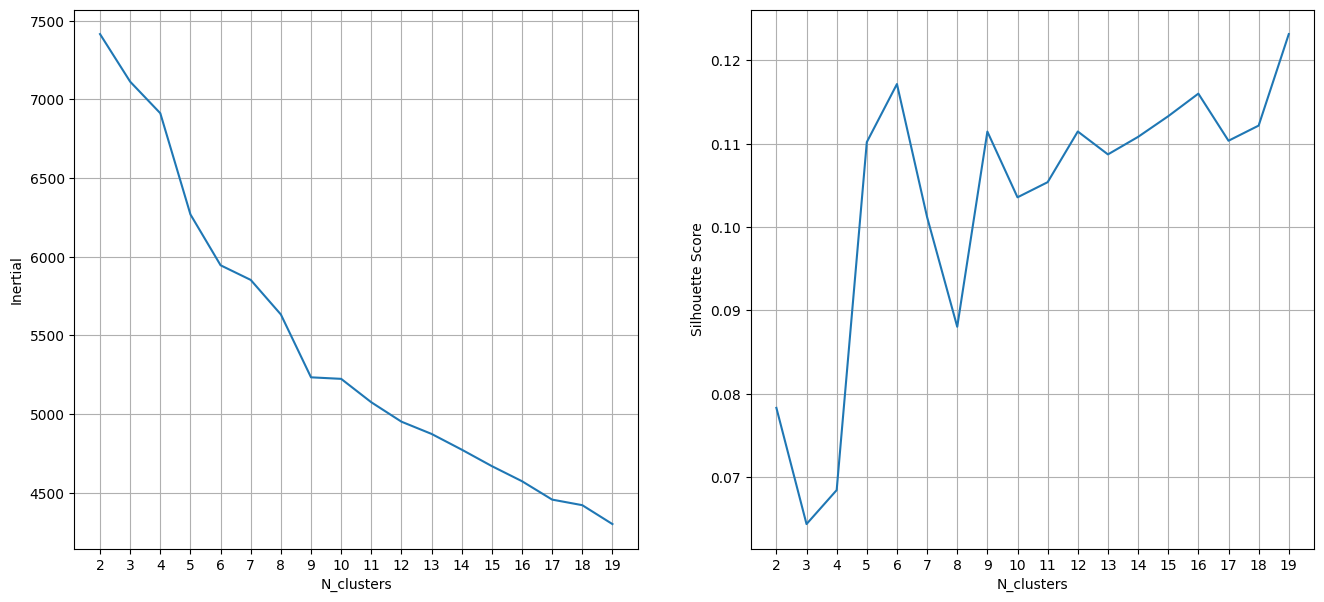

In [9]:
_, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].plot(n_clusters, inertias)
ax[1].plot(n_clusters, sl_scores)
ax[0].set_xlabel("N_clusters")
ax[0].set_ylabel("Inertial")
ax[1].set_xlabel("N_clusters")
ax[1].set_ylabel("Silhouette Score")
ax[0].set_xticks(n_clusters)
ax[1].set_xticks(n_clusters)
ax[0].grid()
ax[1].grid();

### Retrain kmeans with 11 clusters

In [10]:
kmeans = KMeans(n_clusters=11, random_state=42)
kmeans.fit(X_processed_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",11
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
kmeans.inertia_

5074.347286838334

### Analyze the clusters

In [12]:
df_clustered = df.assign(cluster_label = kmeans.labels_)
df_clustered.head()

,age,marital_status,std,educational_background,hiv_test_in_past_year,aids_education,places_of_seeking_sex_partners,sexual_orientation,drug_taking,result,cluster_label
0,22,unmarried,no,college degree,yes,no,bar,heterosexual,yes,positive,10
1,20,unmarried,no,college degree,no,yes,NaN,heterosexual,no,negative,1
2,23,married,yes,college degree,no,yes,NaN,bisexual,no,negative,0
3,24,married,no,college degree,yes,yes,park,heterosexual,yes,positive,7
4,18,unmarried,yes,senior high school,yes,no,internet,heterosexual,yes,positive,1


In [13]:
samples_per_cluster = df_clustered["cluster_label"].value_counts()
samples_per_cluster

cluster_label
3     43
10    40
1     39
5     37
0     35
2     33
7     32
4     31
8     22
9     19
6     18
Name: count, dtype: int64

### Cluster vs Numeric cols

cluster_label
0     44.400000
1     33.307692
2     37.727273
3     22.581395
4     38.741935
5     45.378378
6     32.277778
7     45.500000
8     66.545455
9     46.421053
10    39.550000
Name: age, dtype: float64


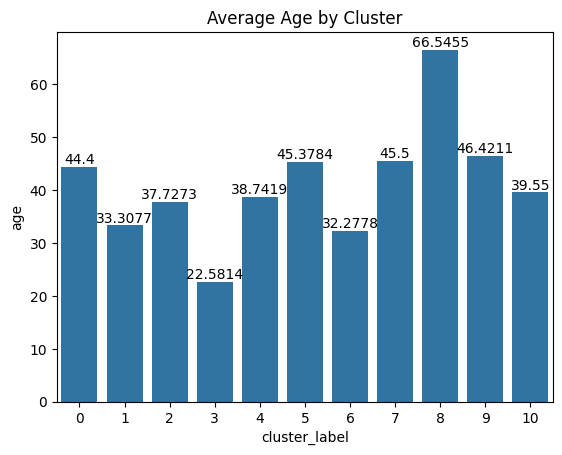

In [14]:
for col in num_col:
    group_average = df_clustered.groupby("cluster_label")[col].mean()
    print(group_average)
    ax = sns.barplot(group_average)
    ax.bar_label(ax.containers[0])
    plt.title(f"Average {col.title()} by Cluster")
    plt.show()

#### Cluster vs categories

marital_status  cohabiting  divorced   married  unmarried   widowed
cluster_label                                                      
0                      0.0  0.000000  1.000000   0.000000  0.000000
1                      0.0  0.000000  0.000000   1.000000  0.000000
2                      0.0  0.030303  0.121212   0.848485  0.000000
3                      0.0  0.000000  0.232558   0.767442  0.000000
4                      0.0  0.000000  0.258065   0.741935  0.000000
5                      0.0  1.000000  0.000000   0.000000  0.000000
6                      1.0  0.000000  0.000000   0.000000  0.000000
7                      0.0  0.312500  0.375000   0.218750  0.093750
8                      0.0  0.136364  0.000000   0.045455  0.818182
9                      0.0  0.000000  0.000000   0.000000  1.000000
10                     0.0  0.000000  0.800000   0.200000  0.000000


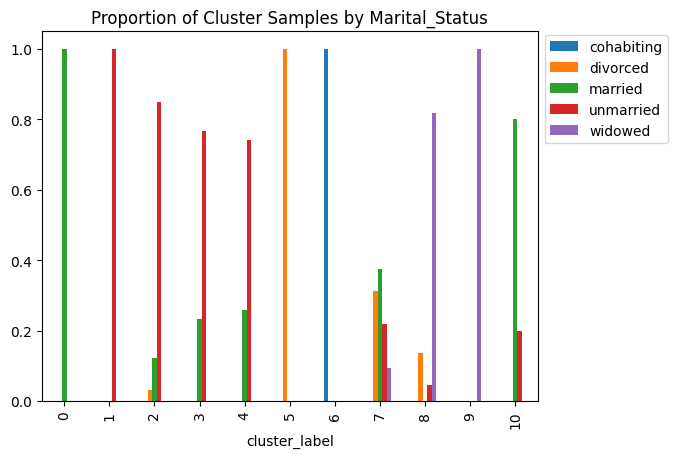

std                  no       yes
cluster_label                    
0              0.371429  0.628571
1              0.666667  0.333333
2              0.363636  0.636364
3              0.581395  0.418605
4              0.677419  0.322581
5              0.540541  0.459459
6              0.333333  0.666667
7              0.562500  0.437500
8              0.545455  0.454545
9              0.421053  0.578947
10             0.575000  0.425000


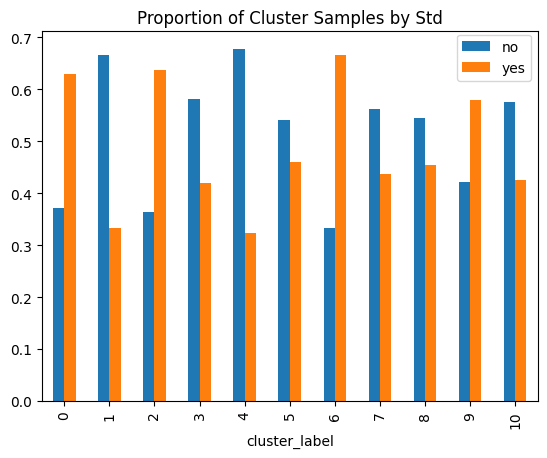

educational_background  college degree  illiteracy  junior high school  \
cluster_label                                                            
0                             0.228571    0.028571            0.000000   
1                             0.282051    0.000000            0.128205   
2                             0.000000    1.000000            0.000000   
3                             0.000000    0.000000            1.000000   
4                             0.516129    0.032258            0.000000   
5                             0.324324    0.135135            0.216216   
6                             0.111111    0.055556            0.388889   
7                             0.562500    0.031250            0.062500   
8                             0.318182    0.500000            0.000000   
9                             0.473684    0.052632            0.052632   
10                            0.875000    0.000000            0.075000   

educational_background  primary schoo

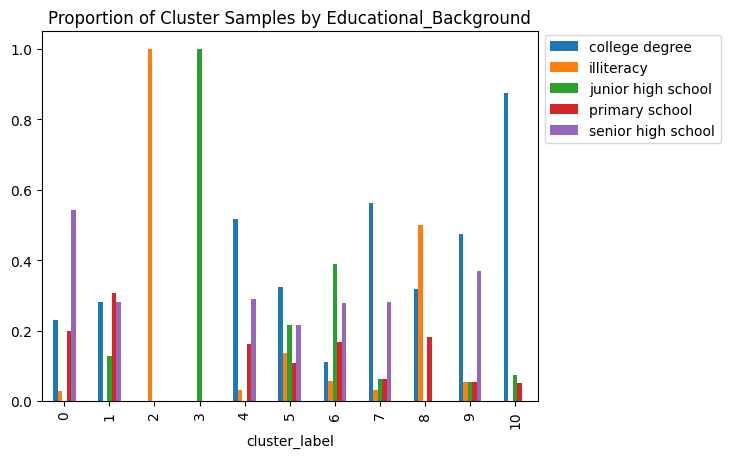

hiv_test_in_past_year        no       yes
cluster_label                            
0                      0.600000  0.400000
1                      0.589744  0.410256
2                      0.787879  0.212121
3                      0.697674  0.302326
4                      0.645161  0.354839
5                      0.594595  0.405405
6                      0.222222  0.777778
7                      0.406250  0.593750
8                      0.818182  0.181818
9                      0.526316  0.473684
10                     0.675000  0.325000


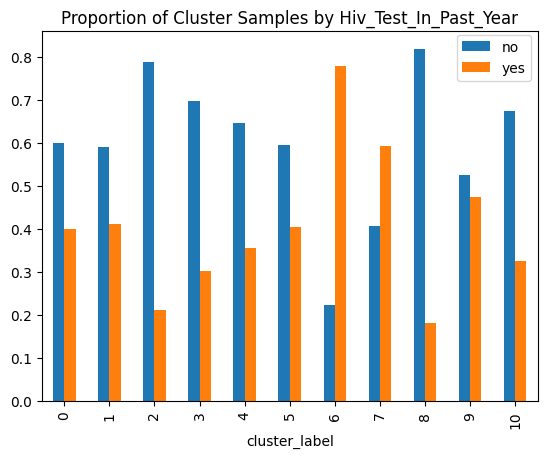

aids_education        no       yes
cluster_label                     
0               0.428571  0.571429
1               0.487179  0.512821
2               0.818182  0.181818
3               0.767442  0.232558
4               0.838710  0.161290
5               0.594595  0.405405
6               0.555556  0.444444
7               0.312500  0.687500
8               0.681818  0.318182
9               0.736842  0.263158
10              0.400000  0.600000


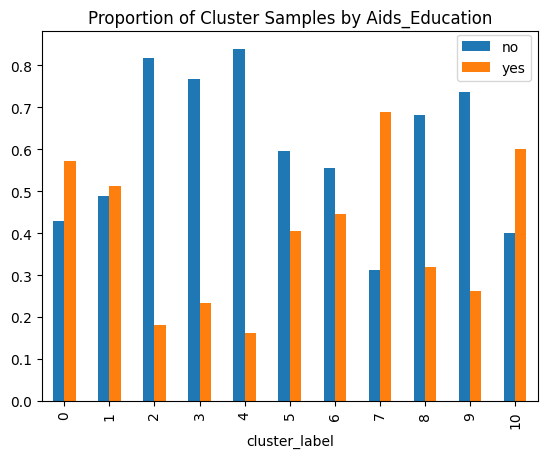

places_of_seeking_sex_partners       bar  internet    others      park  \
cluster_label                                                            
0                               0.090909  0.363636  0.212121  0.000000   
1                               0.117647  0.647059  0.029412  0.000000   
2                               0.333333  0.212121  0.090909  0.242424   
3                               0.209302  0.162791  0.116279  0.139535   
4                               0.225806  0.258065  0.064516  0.000000   
5                               0.285714  0.342857  0.000000  0.057143   
6                               0.333333  0.500000  0.055556  0.000000   
7                               0.000000  0.000000  0.000000  1.000000   
8                               0.000000  0.000000  0.681818  0.181818   
9                               0.117647  0.529412  0.000000  0.117647   
10                              0.550000  0.325000  0.075000  0.000000   

places_of_seeking_sex_partners  publi

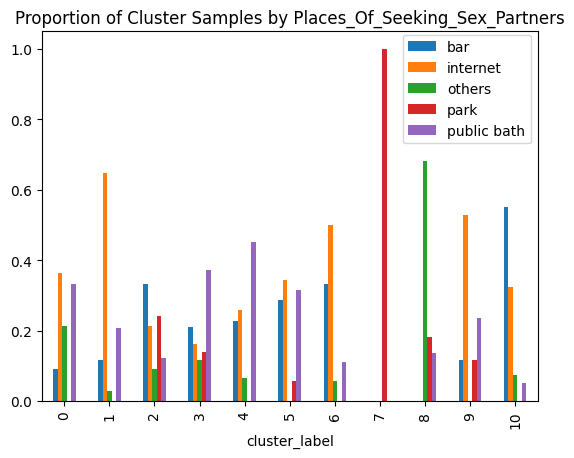

sexual_orientation  bisexual  heterosexual  homosexual
cluster_label                                         
0                   0.400000      0.457143    0.142857
1                   0.128205      0.871795    0.000000
2                   0.303030      0.636364    0.060606
3                   0.232558      0.325581    0.441860
4                   0.000000      0.000000    1.000000
5                   0.324324      0.432432    0.243243
6                   0.000000      0.666667    0.333333
7                   0.281250      0.468750    0.250000
8                   0.136364      0.772727    0.090909
9                   0.473684      0.315789    0.210526
10                  0.075000      0.925000    0.000000


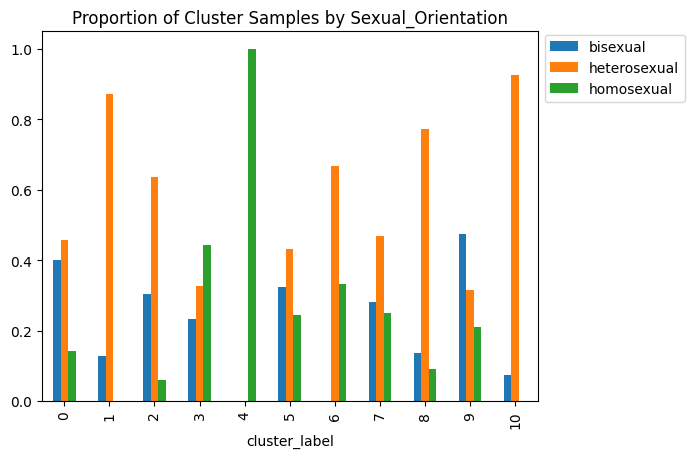

drug_taking          no       yes
cluster_label                    
0              0.542857  0.457143
1              0.615385  0.384615
2              0.424242  0.575758
3              0.627907  0.372093
4              0.483871  0.516129
5              0.702703  0.297297
6              0.666667  0.333333
7              0.468750  0.531250
8              0.454545  0.545455
9              0.789474  0.210526
10             0.575000  0.425000


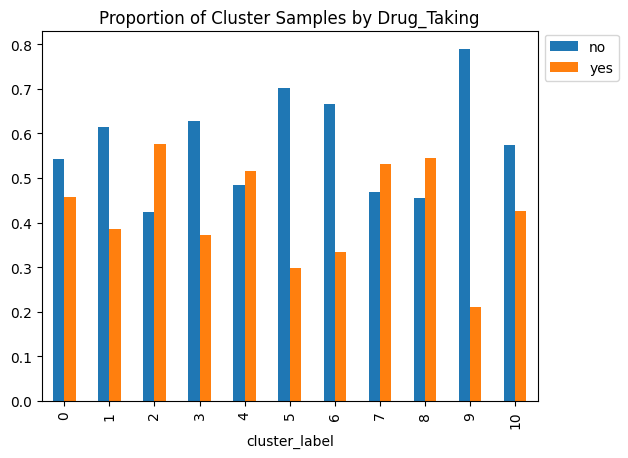

In [15]:
for col in cat_col:
    norm_counts = pd.crosstab(df_clustered[col], df_clustered["cluster_label"], normalize="columns").T
    print(norm_counts)
    norm_counts.plot(kind="bar")
    plt.title(f"Proportion of Cluster Samples by {col.title()}")
    plt.legend(bbox_to_anchor=[1, 1.01])
    plt.show()

### Visualize the clusters

In [16]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(2)
pca.fit(X_processed_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [18]:
pca.explained_variance_ratio_

array([0.09933027, 0.0793015 ])

In [19]:
df_pca = pca.transform(X_processed_scaled)
df_pca.head()

,pca0,pca1
0,0.750752,1.241066
1,0.698540,1.341807
2,-0.789867,0.473120
3,-1.738881,1.513184
4,0.834908,1.688827


<Axes: xlabel='pca0', ylabel='pca1'>

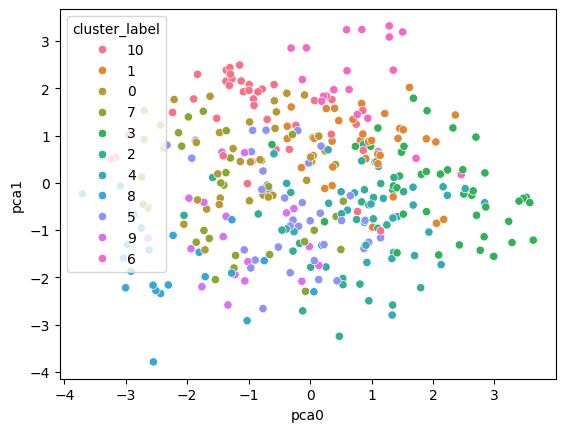

In [20]:
sns.scatterplot(x=df_pca["pca0"], y=df_pca["pca1"], hue=df_clustered["cluster_label"].astype(str))

### Check mutual info between exited and cluster_label

In [21]:
from sklearn.metrics import mutual_info_score

In [22]:
mutual_info_score(df_clustered["result"], df_clustered["cluster_label"])

0.046374006853360565